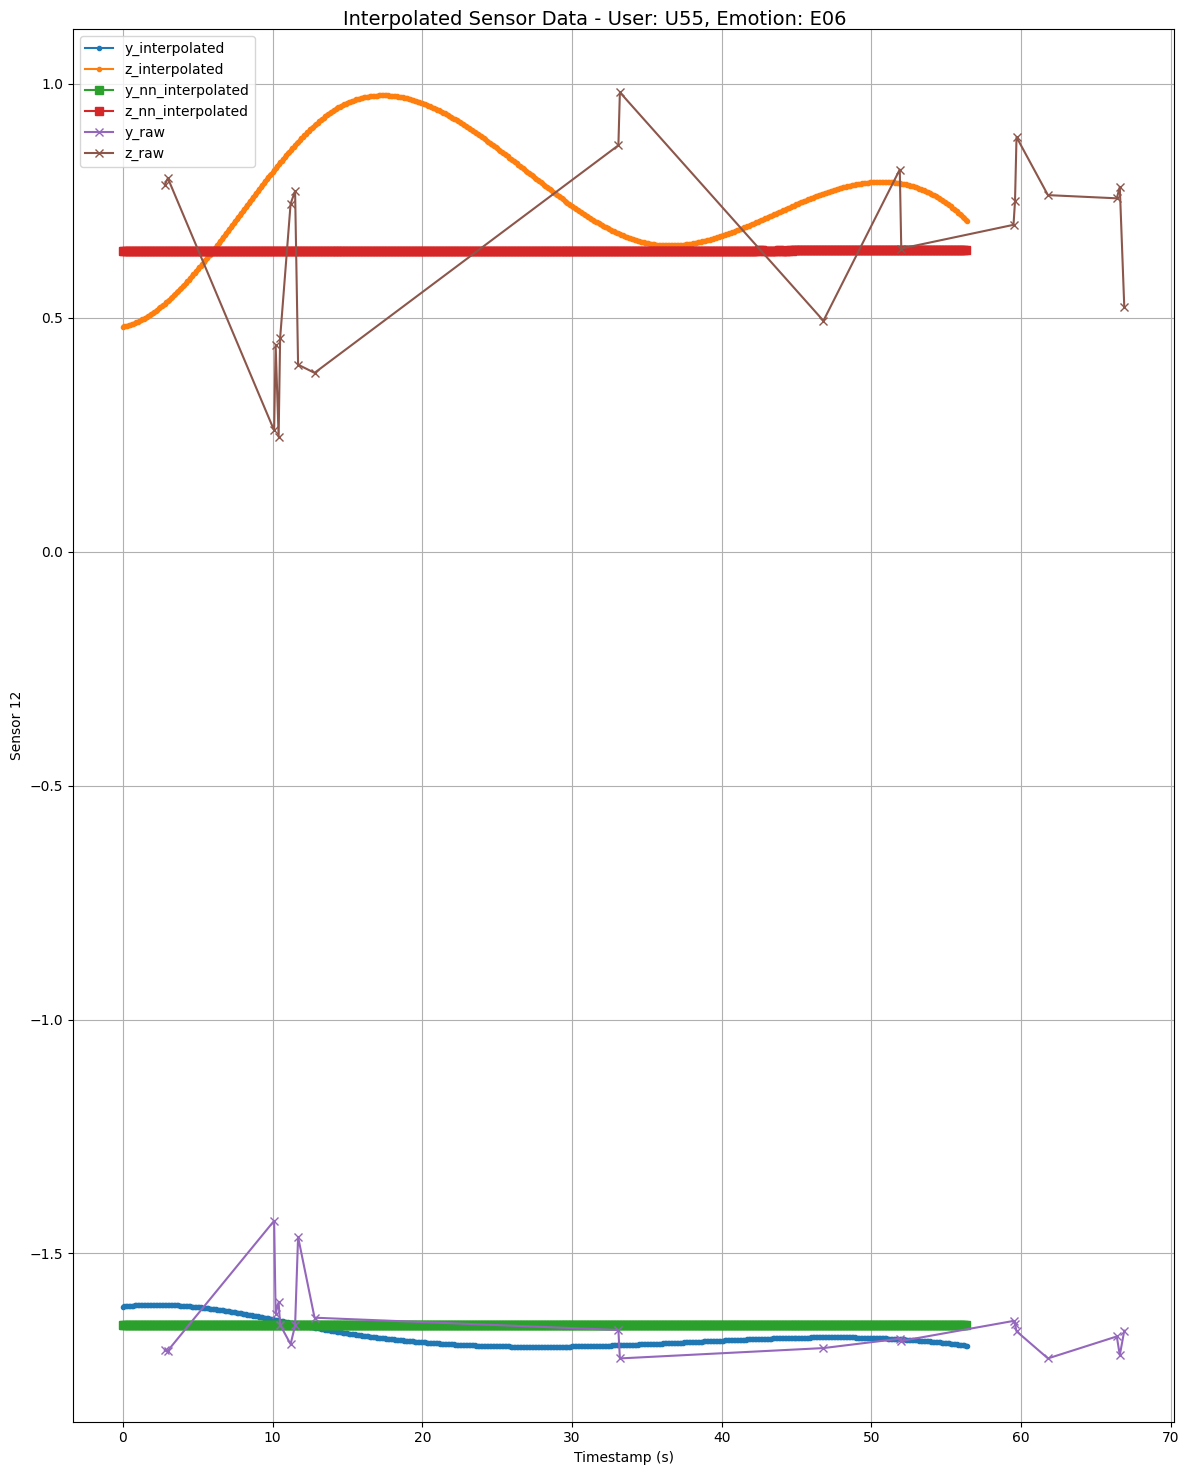

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

raw_data_path = "E:/CoDaS Project/Radar/C3/radar_merged_data.csv"
radar_raw_df = pd.read_csv(raw_data_path)

interp_data_path = "E:/CoDaS Project/Radar/C3/radar_interpolated_merged_data.csv"
radar_interp_df = pd.read_csv(interp_data_path)

nn_interp_data_path = "E:/CoDaS Project/Radar/C3/radar_nn_test_interpolated_data.csv"
nn_interp_df = pd.read_csv(nn_interp_data_path)

# Example: Replace with your desired user_id and emotion
user_id = "U55"  # Change this to your desired user_id
emotion = "E06"  # Change this to your desired emotion label
sensor_id = 12  # Change this to your desired sensor_id (0-12)

# Filter data for the specified user and emotion
raw_df = radar_raw_df[(radar_raw_df['user_id'] == user_id) & (radar_raw_df['emotion'] == emotion)]
interp_df = radar_interp_df[(radar_interp_df['user_id'] == user_id) & (radar_interp_df['emotion'] == emotion)]
nn_interp_df = nn_interp_df[(nn_interp_df['user_id'] == user_id) & (nn_interp_df['emotion'] == emotion)]

# Create subplots for each sensor (13 sensors total)
fig, ax = plt.subplots(1, 1, figsize=(12, 15))
fig.suptitle(f'Interpolated Sensor Data - User: {user_id}, Emotion: {emotion}', fontsize=14)

timestamp = interp_df['timestamp'].values
x_data = interp_df[f'x_{sensor_id}'].values
y_data = interp_df[f'y_{sensor_id}'].values
z_data = interp_df[f'z_{sensor_id}'].values

#ax.plot(timestamp, x_data, label='x_interpolated', marker='.')
ax.plot(timestamp, y_data, label='y_interpolated', marker='.')
ax.plot(timestamp, z_data, label='z_interpolated', marker='.')

timestamp = nn_interp_df['timestamp'].values
x_data = nn_interp_df[f'x_{sensor_id}'].values
y_data = nn_interp_df[f'y_{sensor_id}'].values
z_data = nn_interp_df[f'z_{sensor_id}'].values

#ax.plot(timestamp, x_data, label='x_nn_interpolated', marker='s')
ax.plot(timestamp, y_data, label='y_nn_interpolated', marker='s')
ax.plot(timestamp, z_data, label='z_nn_interpolated', marker='s')

raw_df = raw_df[['timestamp', f'x_{sensor_id}', f'y_{sensor_id}', f'z_{sensor_id}']].dropna()

timestamp = raw_df['timestamp'].values
x_data = raw_df[f'x_{sensor_id}'].values
y_data = raw_df[f'y_{sensor_id}'].values
z_data = raw_df[f'z_{sensor_id}'].values

#ax.plot(timestamp, x_data, label='x_raw', marker='x')
ax.plot(timestamp, y_data, label='y_raw', marker='x')
ax.plot(timestamp, z_data, label='z_raw', marker='x')

ax.set_ylabel(f'Sensor {sensor_id}')
ax.legend()
ax.grid(True)

ax.set_xlabel('Timestamp (s)')
plt.tight_layout()
plt.show()